# Loan Default Prediction - Model results and SHAP explanations

**Goal:** show what the modelling steps produced - model comparison (Step 3), the tuned and calibrated final model
(Step 4), the decision bands and NPA simulation (Step 5) - and explain *why* the model predicts what it predicts,
with SHAP (Step 6).

Everything here is read from files made by the scripts in `src/` (`train.py`, `tune.py`, `business.py`,
`explain.py`); the notebook only shows and explains the results. New charts are saved to `reports/figures/`.

In [1]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT / "src"))
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")   # harmless notice from tqdm (used by shap)
import train  # noqa: F401  - importing it applies the project chart style
%matplotlib inline
from train import INK, INK2, MUTED
from clean_data import APPLICANT_FIELDS
from explain import FEATURE_LABELS, explain_one, get_explainer, reason_text
from load_data import get_splits, load_clean

REPORTS, FIG = PROJECT / "reports", PROJECT / "reports" / "figures"
meta = json.loads((PROJECT / "models" / "model_meta.json").read_text())
BLUE, ORANGE = "#2a78d6", "#eb6834"
pd.set_option("display.precision", 3)

def show(*names, width=720):
    for n in names:
        display(Image(filename=str(FIG / f"{n}.png"), width=width))

## 1. Model comparison (Step 3, validation split)

In [2]:
cmp = pd.read_csv(REPORTS / "model_comparison.csv")
cmp[["model", "cv_auc_mean", "cv_auc_std", "train_auc", "val_roc_auc", "val_pr_auc", "val_ks", "val_recall"]]

,model,cv_auc_mean,cv_auc_std,train_auc,val_roc_auc,val_pr_auc,val_ks,val_recall
0,XGBoost,0.942,0.005,0.995,0.955,0.912,0.772,0.802
1,XGBoost + SMOTE,0.943,0.004,0.991,0.952,0.912,0.771,0.751
2,Random Forest,0.930,0.006,1.000,0.940,0.896,0.748,0.712
3,Logistic Regression,0.873,0.005,0.873,0.879,0.726,0.601,0.791


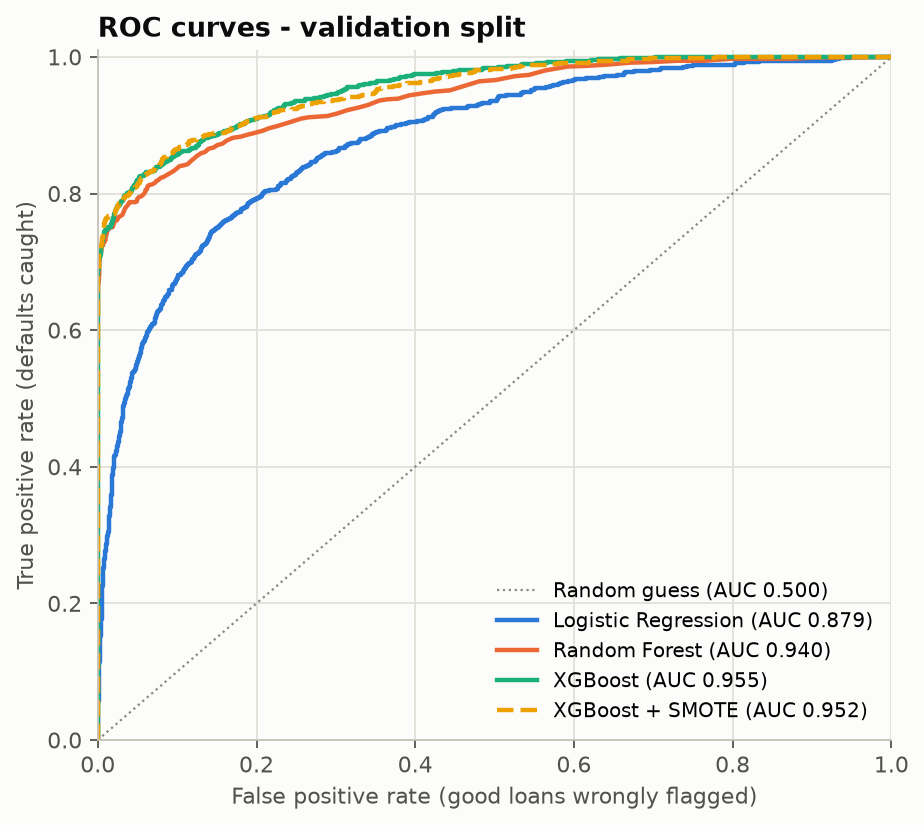

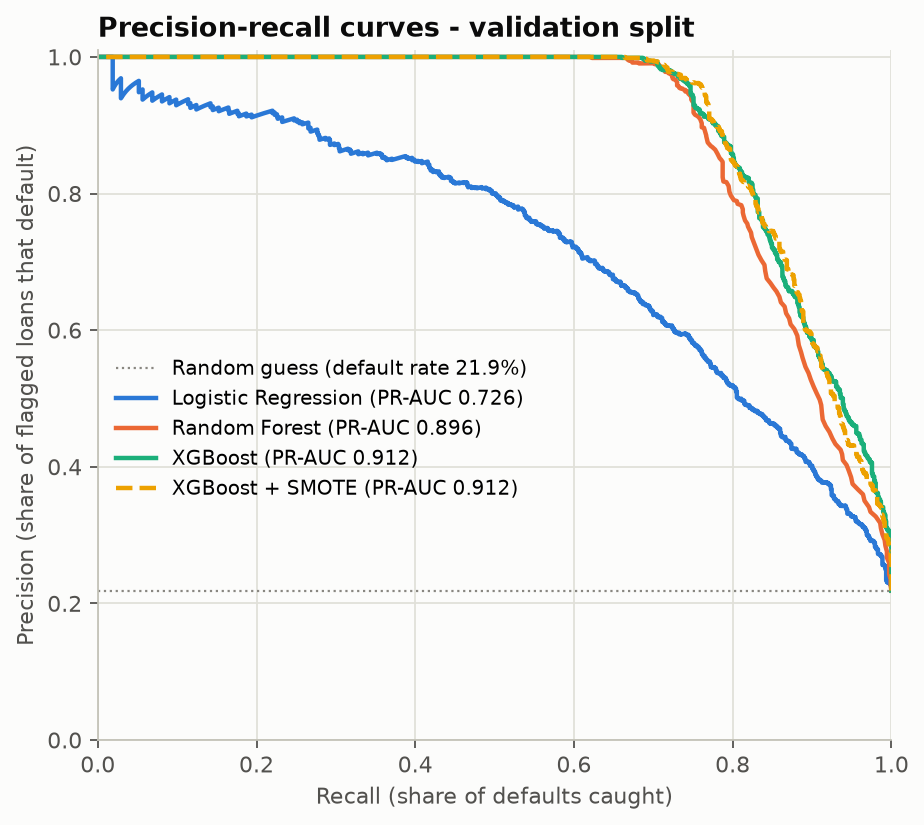

In [3]:
show("13_roc_curves_validation", "14_pr_curves_validation", width=520)

**Insight:** the tree models beat Logistic Regression clearly: **XGBoost 0.955** validation ROC-AUC (CV 0.942) vs **0.879** for Logistic Regression - the data has step patterns (grade C->D, loan above 30% of income, renters) that a straight-line model cannot follow. SMOTE gave no real gain (0.952; CV +0.001, within noise) and Random Forest memorised the training data (train AUC 1.000, validation 0.940). XGBoost with `scale_pos_weight` was chosen for tuning.

## 2. Final model (Step 4)

In [4]:
t = meta["test"]
print(f"Model: {meta['model_type']} (MLflow '{meta['model_name']}' version {meta['version']}, alias production)")
print(f"Best CV ROC-AUC {meta['best_cv_auc']:.3f} | train {meta['train_auc_tuned']:.3f} | validation {meta['val_tuned']['roc_auc']:.3f}")
pd.Series({"ROC-AUC": t["roc_auc"], "PR-AUC": t["pr_auc"], "KS": t["ks"], "Brier score": t["brier"],
           "Calibration error (ECE)": t["ece"], "Precision @0.5": t["precision"], "Recall @0.5": t["recall"]},
          name="test split (used once)").to_frame()

Model: XGBoost pipeline + isotonic calibration (MLflow 'loan_default_model' version 1, alias production)
Best CV ROC-AUC 0.946 | train 0.986 | validation 0.957


,test split (used once)
ROC-AUC,0.952
PR-AUC,0.909
KS,0.767
Brier score,0.051
Calibration error (ECE),0.004
Precision @0.5,0.975
Recall @0.5,0.726


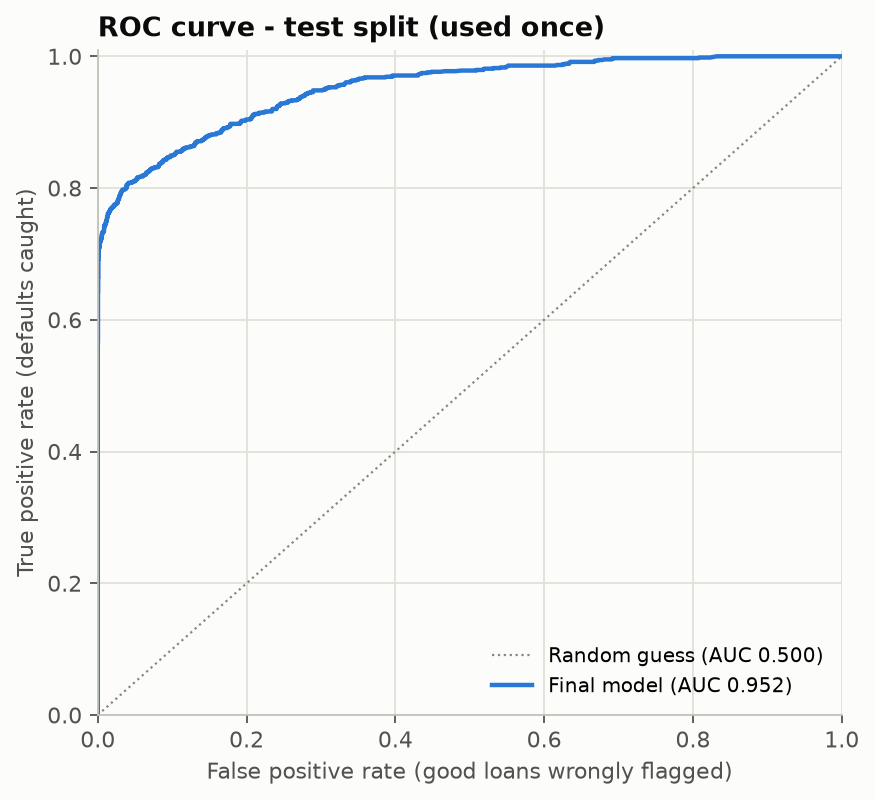

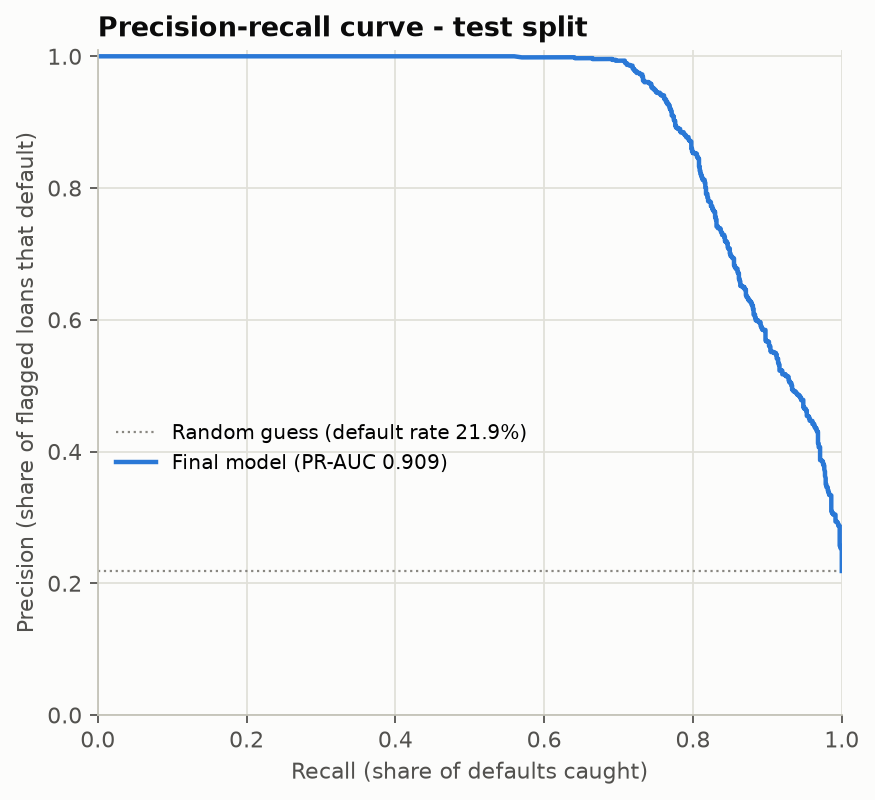

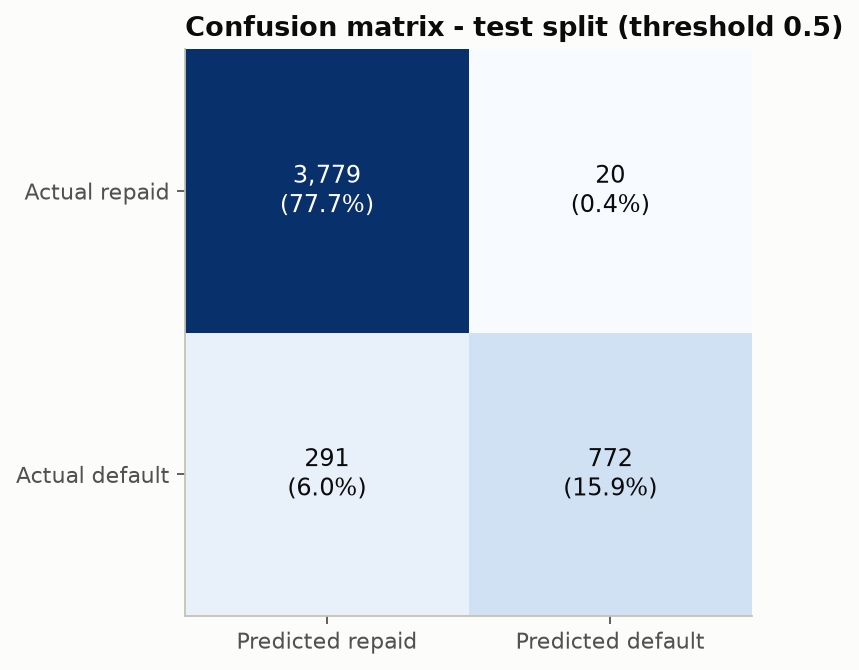

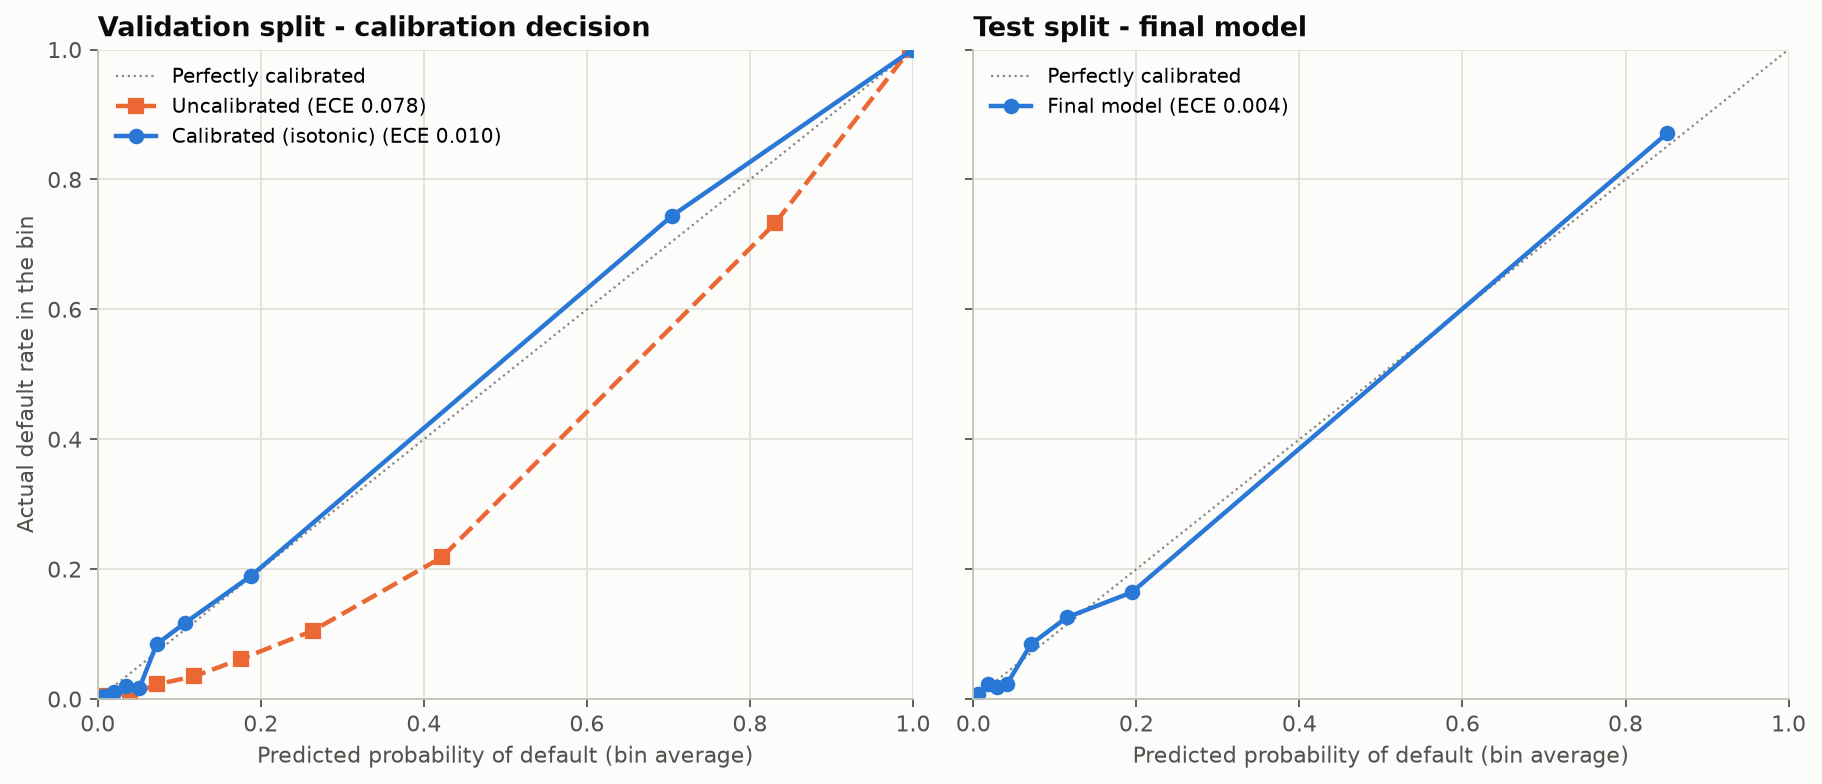

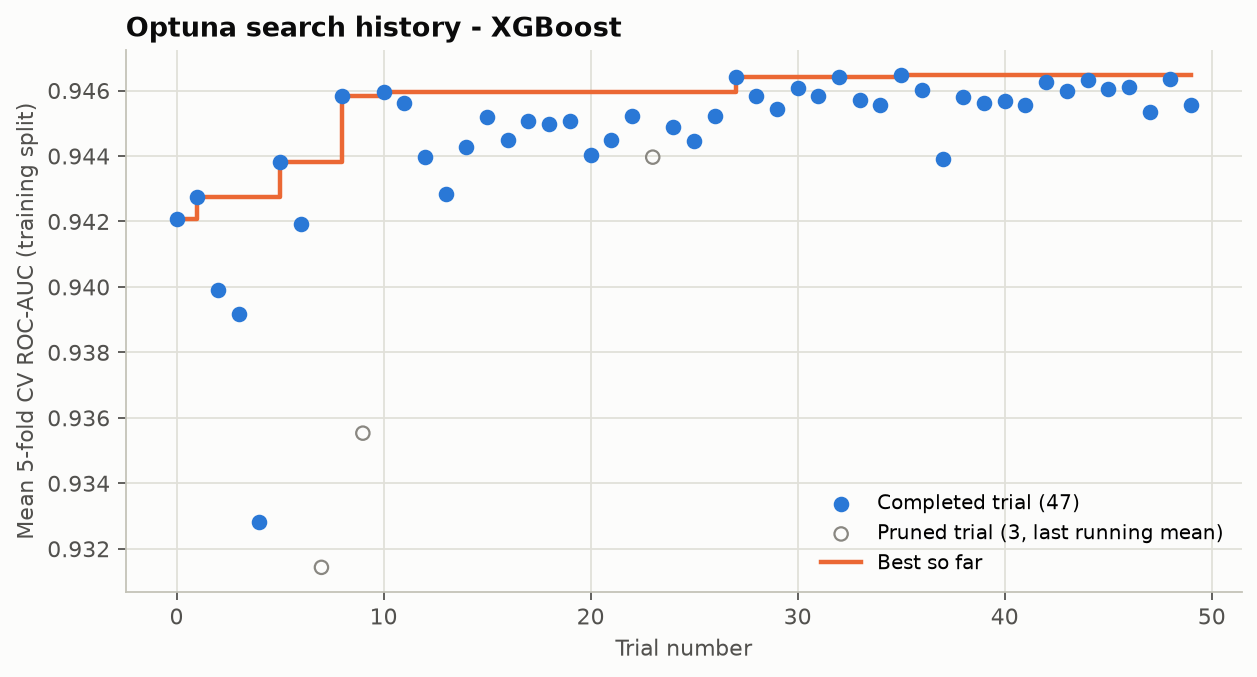

In [5]:
show("15_test_roc", "16_test_pr", "17_confusion_matrix", width=470); show("18_calibration", "19_optuna_history", width=820)

**Insight:** tuning raised the CV ROC-AUC from 0.942 to **0.946** and shrank the train - validation gap from 0.040 to **0.028** (less overfitting). `scale_pos_weight` made the probabilities too high (calibration error 0.078 on validation); isotonic calibration fixed it (0.010) without changing the ranking. On the **test split, used once**, the final model scores **ROC-AUC 0.952**, PR-AUC 0.909, KS 0.767 and a calibration error of only 0.004 - the 0.85 target is met without leakage. At threshold 0.5 it is very precise (0.975) but catches 72.6% of defaults; the decision bands below use better cut-offs.

## 3. Decision bands and NPA reduction (Step 5)

In [6]:
cut = meta["decision_cutoffs"]
print(f"APPROVE p < {cut['review']}  |  REVIEW {cut['review']} <= p < {cut['reject']}  |  REJECT p >= {cut['reject']}")
sim = pd.read_csv(REPORTS / "business_simulation.csv").set_index("policy")
sim[["loans_approved", "defaults_approved", "default_amount_approved", "npa_reduction_count", "npa_reduction_amount",
     "good_loans_lost", "net_result"]]

APPROVE p < 0.1  |  REVIEW 0.1 <= p < 0.35  |  REJECT p >= 0.35


,loans_approved,defaults_approved,default_amount_approved,npa_reduction_count,npa_reduction_amount,good_loans_lost,net_result
policy,,,,,,,
Baseline: approve everyone,4862,1063,1.144e+07,0.000,0.000,0,-7.723e+06
Scenario A: REVIEW approved,4005,257,2.309e+06,0.758,0.798,51,1.339e+06
Scenario B: REVIEW rejected,3020,89,7.949e+05,0.916,0.931,868,1.955e+06


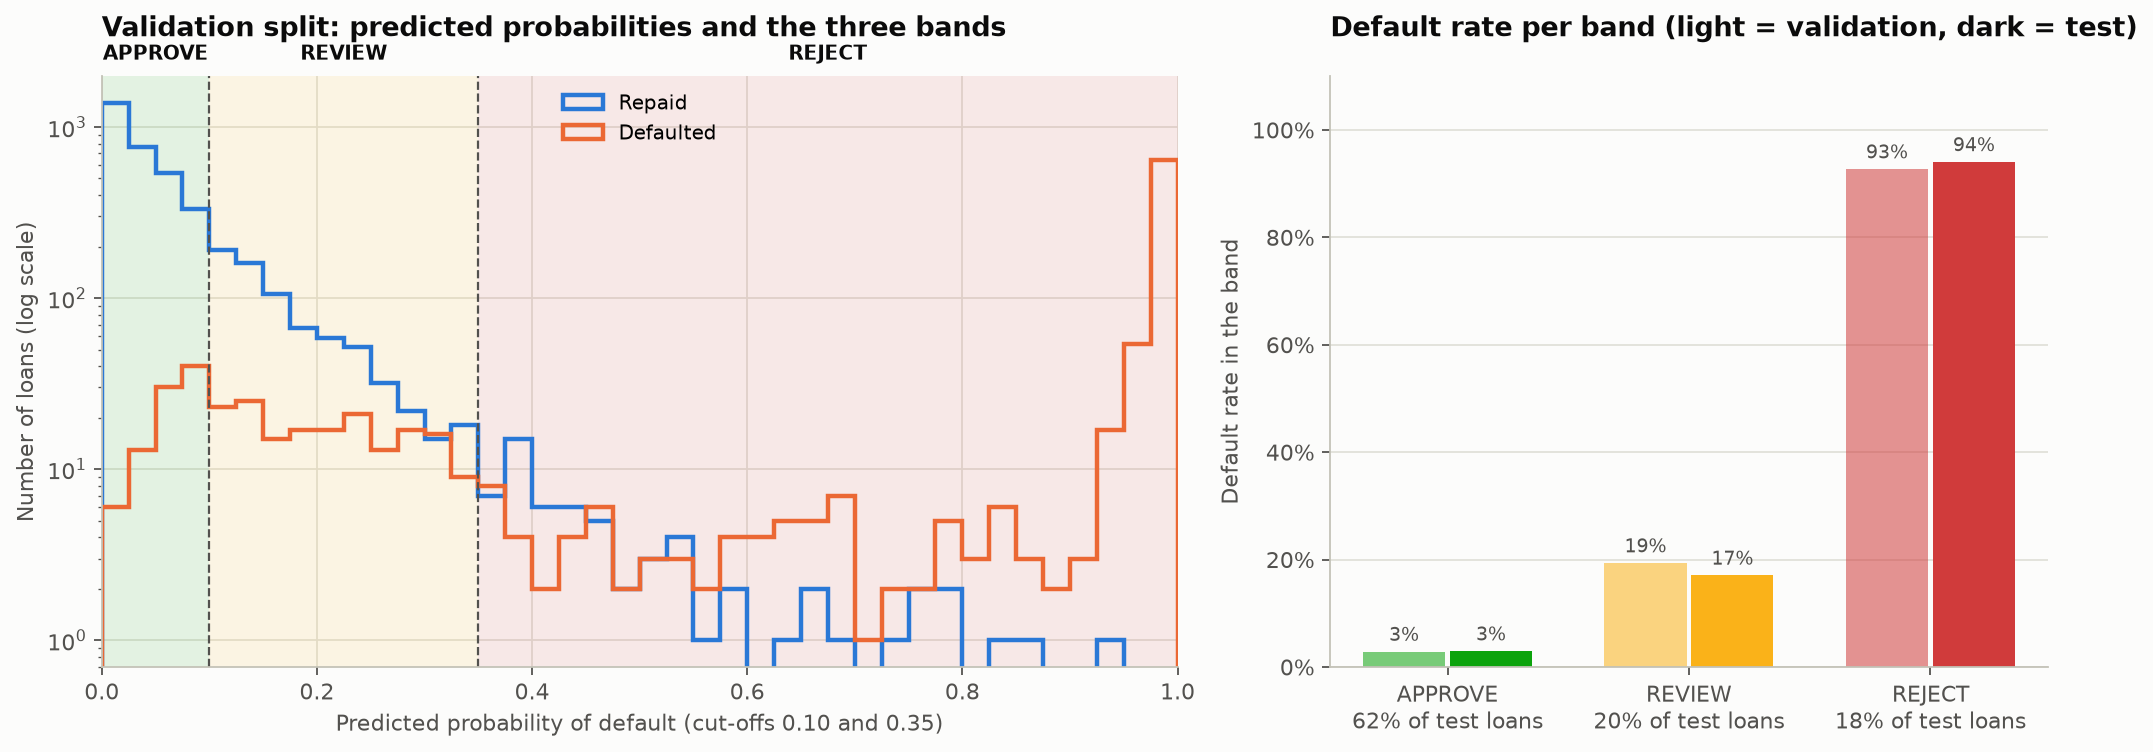

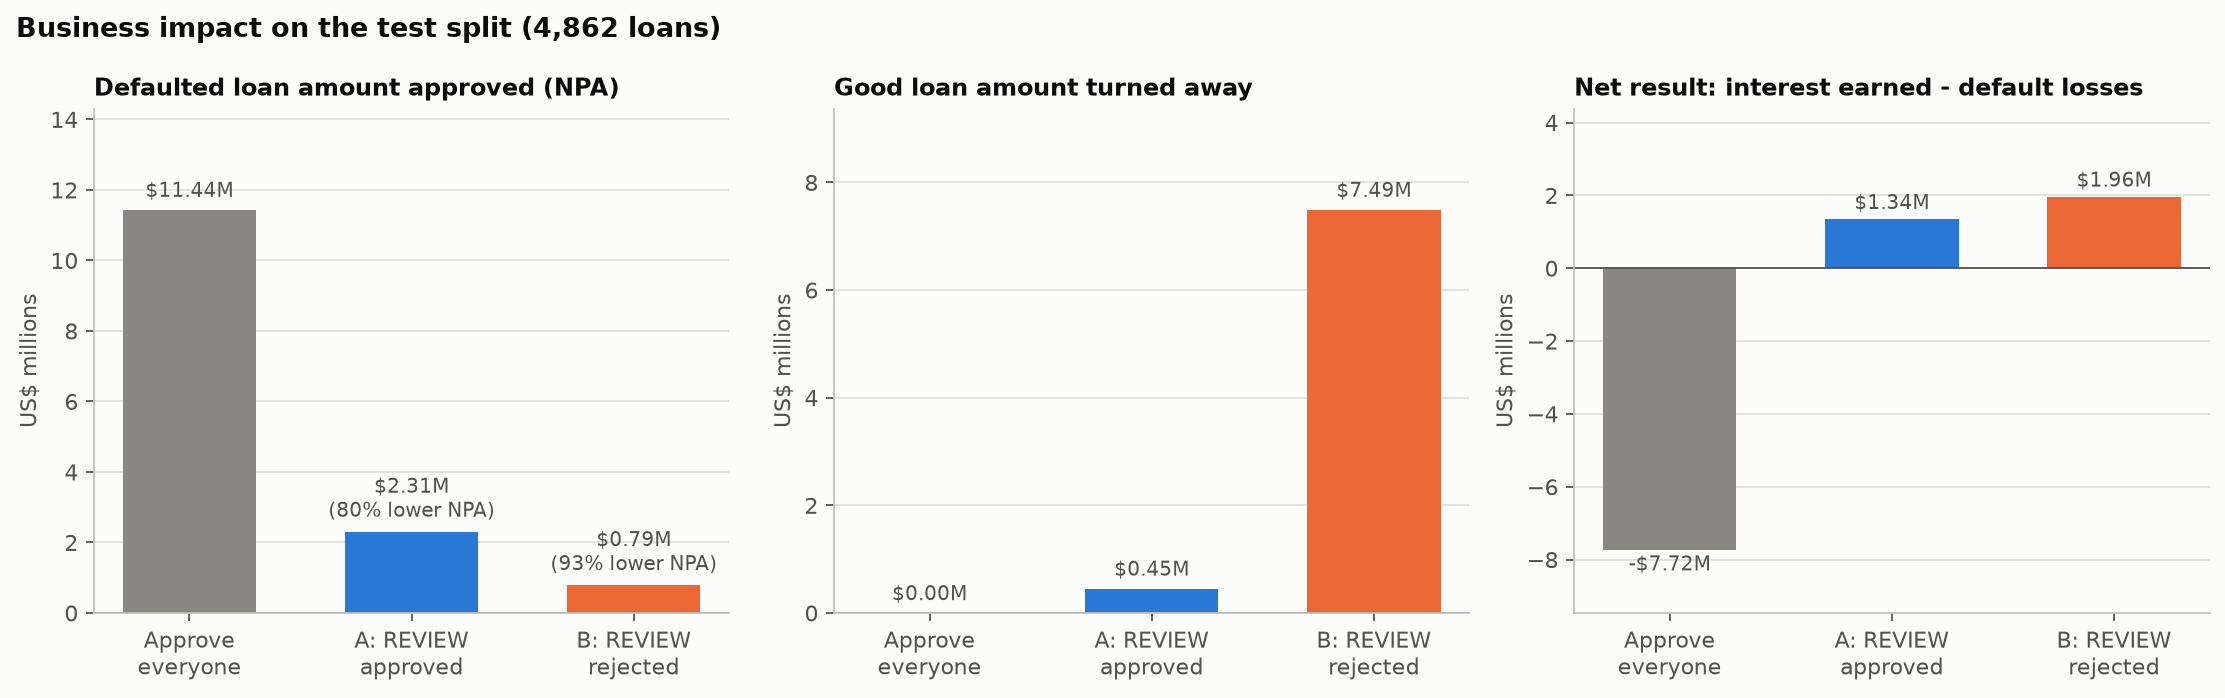

In [7]:
show("20_decision_bands", "21_npa_reduction", width=900)

**Insight:** with APPROVE below 0.10 and REJECT from 0.35, the test split shows **1,063 defaults if everyone is approved**, but only **257** if REVIEW loans are approved (scenario A, **79.8% less defaulted money**) or **89** if REVIEW loans are rejected (scenario B, **93.1%**). Scenario A turns away only 51 good borrowers (1.3%); scenario B turns away 868 (22.8%). Both beat the 30% NPA target - but against an "approve everyone" baseline, on a dataset with a perfect rule, with a simple money model (see `reports/business_simulation.md`).

## 4. SHAP - which features drive the model?
SHAP splits every prediction into a contribution per feature: positive = pushes towards default, negative = towards
repaid. The final model averages 3 calibrated XGBoost pipelines, so `src/explain.py` explains each inner XGBoost model
and averages the results (in log-odds). One-hot columns are added back to their original feature.

In [8]:
ex = get_explainer()
imp = pd.read_csv(REPORTS / "shap_importance.csv")
imp[["rank", "label", "mean_abs_shap", "share", "direction"]]

,rank,label,mean_abs_shap,share,direction
0,1,Yearly income,1.084,0.214,higher value -> lower risk (lowest 20% of valu...
1,2,Loan grade,0.882,0.174,higher value -> higher risk (lowest 20% of val...
2,3,Loan as % of income,0.752,0.149,higher value -> higher risk (lowest 20% of val...
3,4,Home ownership,0.726,0.144,"lowest risk: OWN (-4.32), highest risk: RENT (..."
4,5,Loan purpose,0.589,0.117,"lowest risk: VENTURE (-1.57), highest risk: HO..."
5,6,Interest rate,0.360,0.071,higher value -> higher risk (lowest 20% of val...
6,7,Loan amount,0.299,0.059,higher value -> higher risk (lowest 20% of val...
7,8,Years employed,0.169,0.033,higher value -> lower risk (lowest 20% of valu...
8,9,Age,0.131,0.026,higher value -> lower risk (lowest 20% of valu...
9,10,Credit history length,0.047,0.009,higher value -> lower risk (lowest 20% of valu...


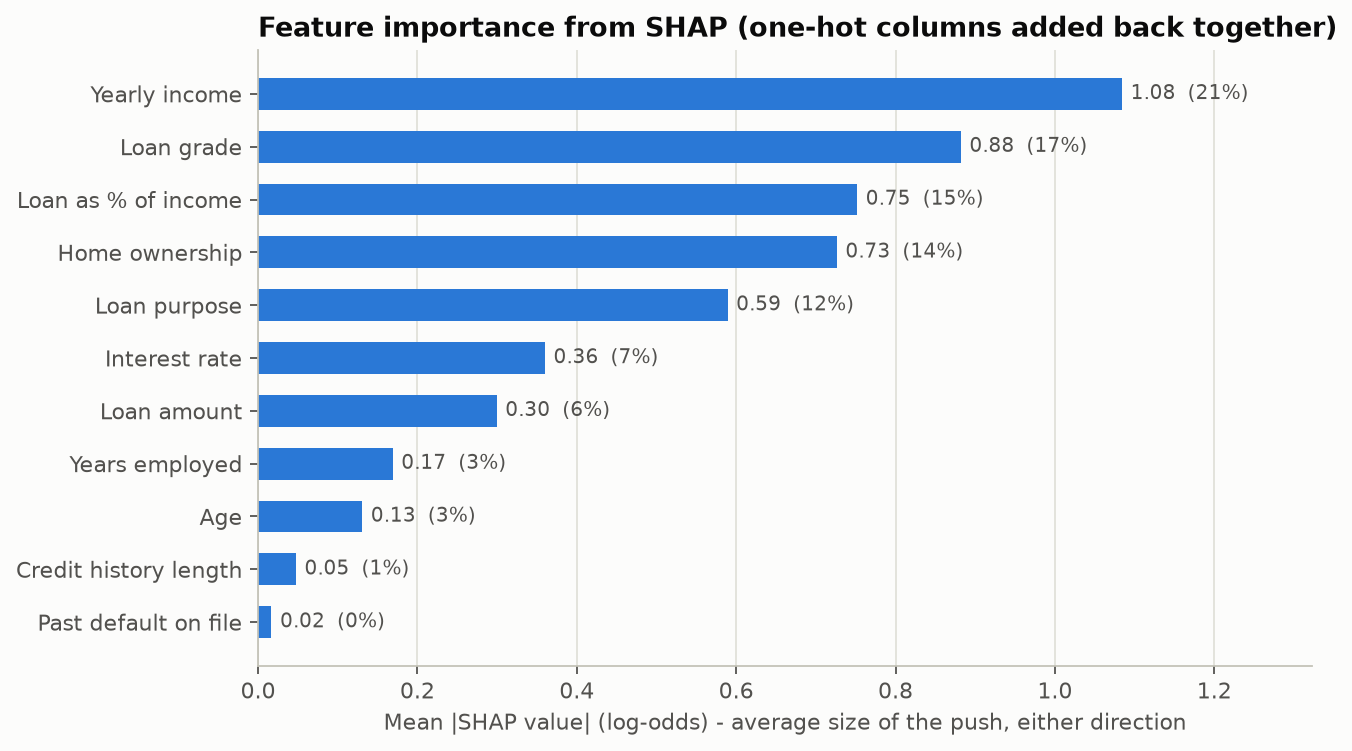

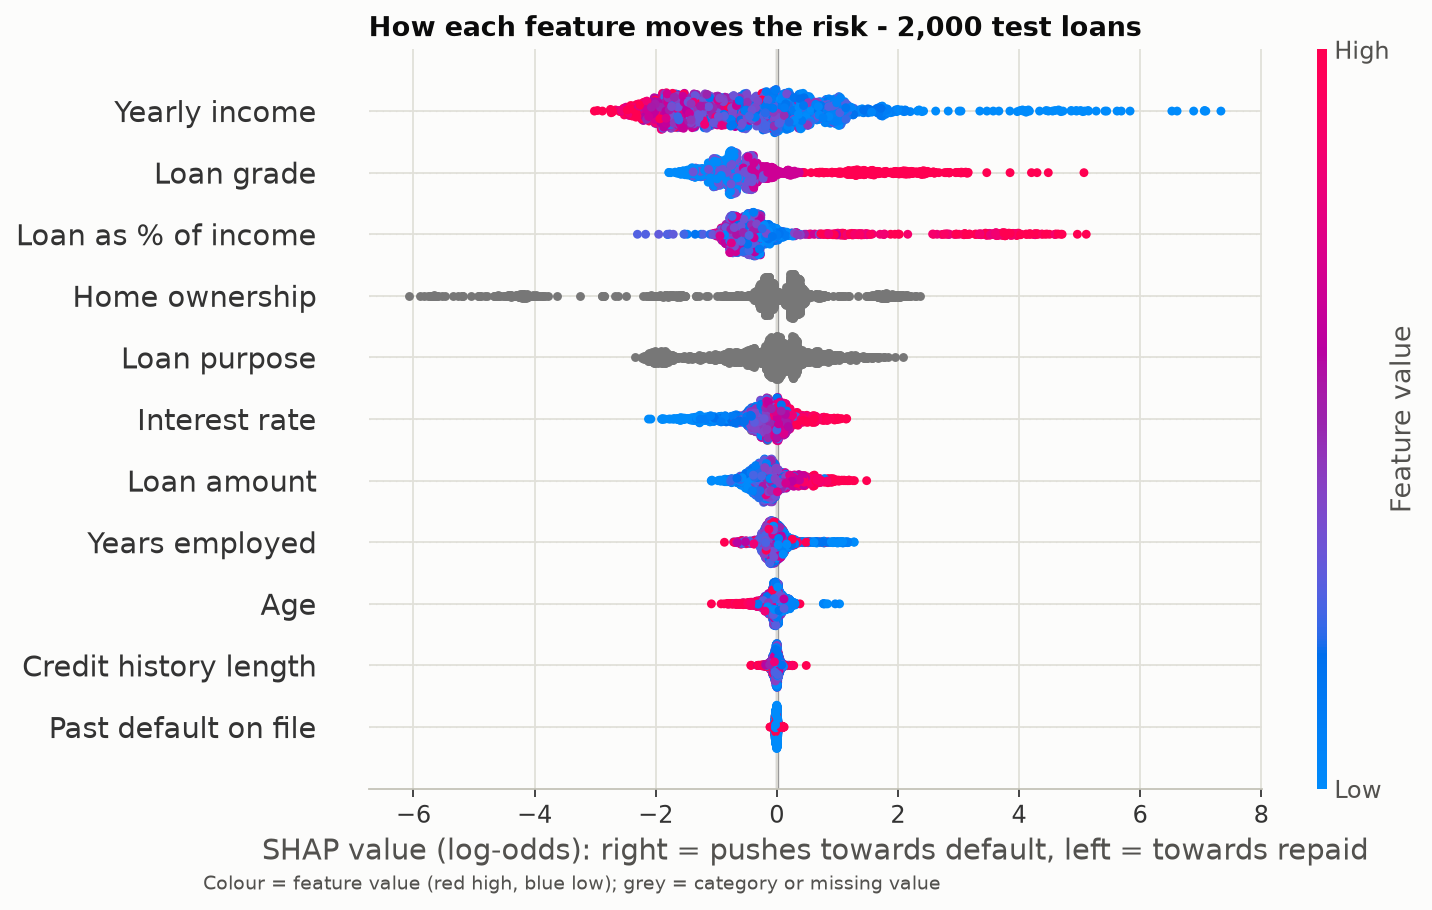

In [9]:
show("23_shap_importance_bar", "22_shap_summary_beeswarm", width=760)

**Insight:** **yearly income (21%)**, **loan grade (17%)** and **loan as % of income (15%)** carry 54% of the SHAP importance, followed by **home ownership (14%)** and **loan purpose (12%)**. In the beeswarm, high incomes (red) sit on the left (lower risk) and high grades / high loan-to-income on the right (higher risk). **Past default on file has almost no weight (0.3%)** even though past defaulters default twice as often in the EDA - the grade already contains that information, so the model uses the grade.

### Loan as % of income: a switch, not a slope
A dependence plot: each dot is one test loan, its loan-to-income ratio (x) against its SHAP contribution (y).

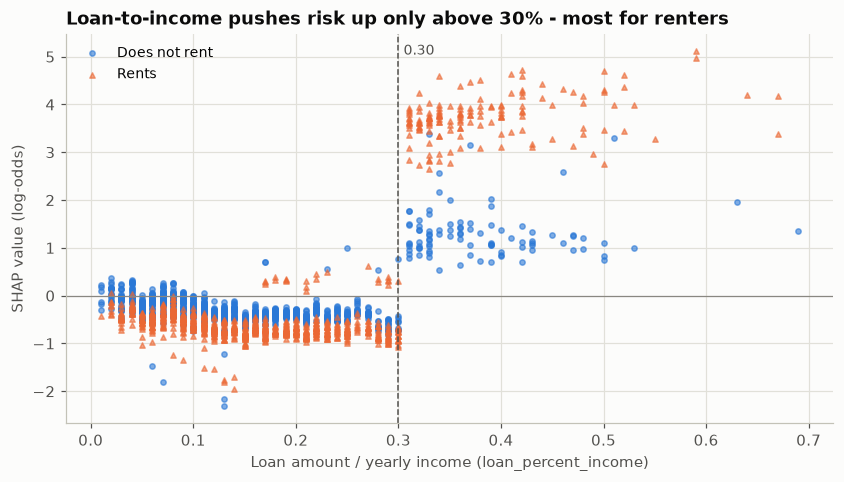

,loans,mean_shap,default_rate
group,,,
"above 0.30, does not rent",92,1.307,0.261
"above 0.30, rents",146,3.733,1.000
up to 0.30,1762,-0.451,0.155


In [10]:
d = get_splits()
X = d["X_test"].sample(2000, random_state=42)
s = ex.shap_by_feature(X)
renter = X["person_home_ownership"] == "RENT"
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.scatter(X.loc[~renter, "loan_percent_income"], s.loc[~renter, "loan_percent_income"], s=12, color=BLUE, alpha=0.6, label="Does not rent")
ax.scatter(X.loc[renter, "loan_percent_income"], s.loc[renter, "loan_percent_income"], s=12, marker="^", color=ORANGE, alpha=0.6, label="Rents")
ax.axvline(0.30, color=INK2, ls="--", lw=1)
ax.axhline(0, color=MUTED, lw=0.8)
ax.text(0.305, ax.get_ylim()[1] * 0.92, "0.30", color=INK2, fontsize=9)
ax.set_xlabel("Loan amount / yearly income (loan_percent_income)")
ax.set_ylabel("SHAP value (log-odds)")
ax.set_title("Loan-to-income pushes risk up only above 30% - most for renters")
ax.legend(loc="upper left", fontsize=9)
fig.savefig(FIG / "24_shap_loan_percent_income.png")
plt.show()
stretched = X["loan_percent_income"] > 0.30
pd.DataFrame({"group": np.select([stretched & renter, stretched & ~renter], ["above 0.30, rents", "above 0.30, does not rent"], default="up to 0.30"),
              "shap": s["loan_percent_income"], "defaulted": d["y_test"].loc[X.index]}).groupby("group").agg(
    loans=("shap", "size"), mean_shap=("shap", "mean"), default_rate=("defaulted", "mean"))

**Insight:** loan-to-income is a **switch, not a slope**. Up to 30% of income its SHAP value is slightly negative (average **-0.45**; these loans default 15.5%). Above 30% it jumps: **+1.31** for borrowers who do not rent (26.1% default) and **+3.73** for renters - and all 146 renters above 30% in this sample defaulted (100%). This is the "perfect rule" from Step 3, seen from inside the model.

## 5. Explaining single applicants
`explain_one(applicant)` is what the API will call: it takes the 11 raw fields, returns the calibrated probability,
the decision band and the top 5 reasons. Three real test loans: one from each band.

In [11]:
clean = load_clean()

def as_applicant(i):
    """Raw applicant fields of a cleaned row (grade letter, Y/N), as the API receives them."""
    row = clean.loc[i]
    a = {f: row[f] for f in APPLICANT_FIELDS}
    a["cb_person_default_on_file"] = "Y" if row["cb_person_default_on_file"] == 1 else "N"
    return {k: (None if isinstance(v, float) and np.isnan(v) else v) for k, v in a.items()}

p = ex.predict_proba(X)
targets = {"APPROVE": 0.03, "REVIEW": 0.20, "REJECT": 0.60}        # pick a typical loan from each band
chosen = {band: X.index[np.argmin(np.abs(p - target))] for band, target in targets.items()}
results = {}
for band, i in chosen.items():
    r = explain_one(as_applicant(i))
    results[band] = r
    print(f"{band:8s} loan_id {clean.loc[i, 'loan_id']}: probability {r['probability']:.1%} -> {r['decision']} "
          f"(actually {'defaulted' if clean.loc[i, 'loan_status'] == 1 else 'repaid'})")
    for line in reason_text(r["reasons"]):
        print("    -", line)

APPROVE  loan_id 11464: probability 3.0% -> APPROVE (actually repaid)
    - Loan for a business venture - decreases risk
    - Yearly income of $45,000 - decreases risk
    - Loan is 9% of yearly income - decreases risk
    - Loan amount of $4,000 - decreases risk
    - 5 years employed - decreases risk
REVIEW   loan_id 25240: probability 20.0% -> REVIEW (actually repaid)
    - Grade D loan - increases risk
    - Yearly income of $82,000 - decreases risk
    - Loan amount of $25,000 - increases risk
    - Loan is 30% of yearly income - decreases risk
    - Has a mortgage - decreases risk
REJECT   loan_id 19991: probability 60.5% -> REJECT (actually repaid)
    - Grade D loan - increases risk
    - Yearly income of $45,000 - decreases risk
    - Loan for medical bills - increases risk
    - Interest rate of 16.3% - increases risk
    - Loan amount of $3,600 - decreases risk


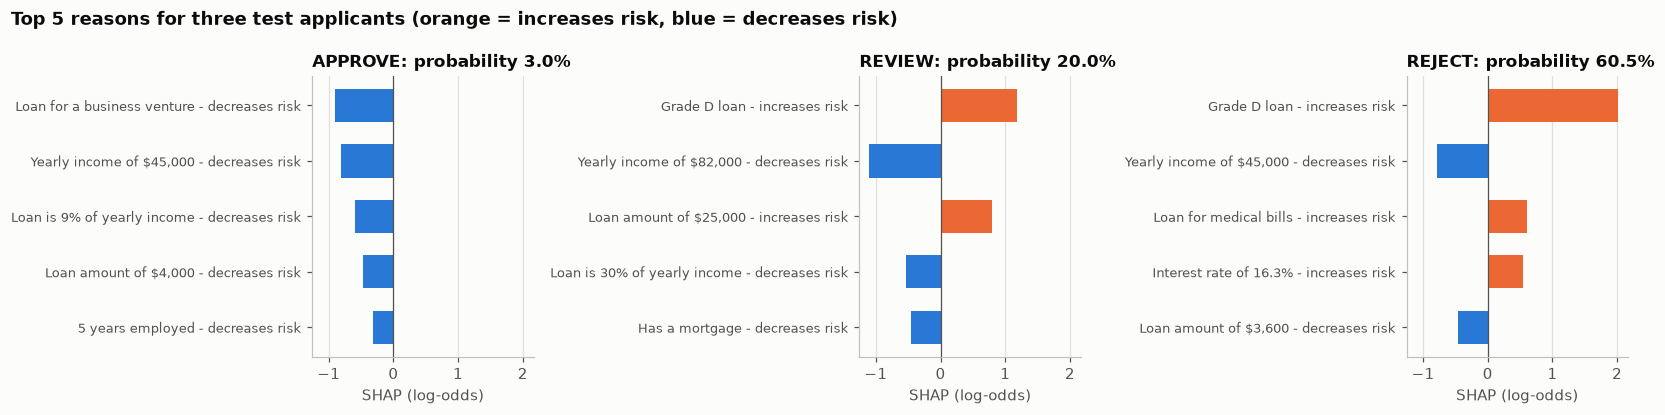

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharex=True)
for ax, (band, r) in zip(axes, results.items()):
    reasons = r["reasons"][::-1]
    vals = [x["contribution"] for x in reasons]
    ax.barh(reason_text(reasons), vals, color=[ORANGE if v > 0 else BLUE for v in vals], height=0.6)
    ax.axvline(0, color=INK2, lw=0.8)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.set_title(f"{band}: probability {r['probability']:.1%}", fontsize=11)
    ax.set_xlabel("SHAP (log-odds)")
fig.suptitle("Top 5 reasons for three test applicants (orange = increases risk, blue = decreases risk)",
             x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
fig.savefig(FIG / "25_shap_three_applicants.png")
plt.show()

**Insight:** each applicant gets reasons a loan officer can read. The **APPROVE** loan (3.0%) is a small venture loan, only 9% of a $45,000 income. The **REVIEW** loan (20.0%) is a grade D loan of $25,000 - the grade pushes risk up, but an $82,000 income, a mortgage and a loan just at 30% of income pull it down, so a person should decide. The **REJECT** loan (60.5%: grade D, medical, 16.3% interest) actually **repaid** - a reminder that 60% means "about 6 in 10 such loans default", not certainty; that is why REJECT starts at 0.35 and why the probability, not just the band, is shown.

## 6. Summary

| Step | Result |
|---|---|
| Model comparison | XGBoost best (validation 0.955), trees beat Logistic Regression (0.879) |
| Final model | Tuned + calibrated XGBoost, **test ROC-AUC 0.952**, calibration error 0.004 |
| Decision bands | APPROVE < 0.10 <= REVIEW < 0.35 <= REJECT (chosen on validation) |
| NPA reduction | **79.8%** (REVIEW approved) to **93.1%** (REVIEW rejected) of defaulted money vs approving everyone |
| Explainability | Income, grade and loan-to-income drive the model (54%); loan-to-income acts as a switch at 30% |

Caveat for the report: the dataset contains a perfect rule (renters above 30% of income always default), so these numbers are likely higher than on real lending data.